# 栅极电离室：实验波形、成型与物理量提取

[上一节](GIC_simulation.html)从电离径迹得到感应电流、积分电荷和前放电压。这一节从实际记录的 ADC 波形出发，依次进行基线修正、波形观察、pole-zero correction 和梯形成型，再提取幅度、时间及阴极—阳极关联。

本例使用同一 GIC 装置的实验数据。阴极为正脉冲，阳极为负脉冲；两路每条记录均为 4096 点，采样间隔 10 ns。配套文件 `gic_experiment.root` 保留 `fall.root` 的全部 5500 条记录，未更改采样值或顺序。数据由刘杰、崔增祺提供。运行代码时，将配套数据放在 notebook 同一目录。

## 1. 读取原始波形

`TTree` 中 `cathod[4096]` 与 `anode[4096]` 保存同一事件的两路波形。横轴要从 sample index 换算为时间；没有电压刻度时，纵轴保留 ADC channel，不能写成 mV。

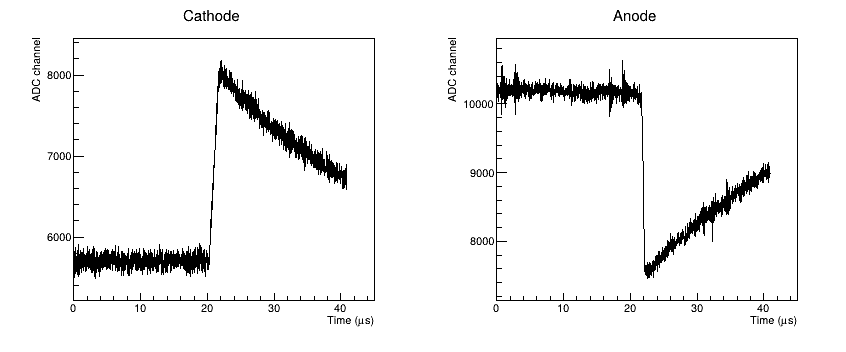

In [ ]:
gStyle->SetOptStat(0);
gStyle->SetPadLeftMargin(.16);
gStyle->SetPadBottomMargin(.14);
gStyle->SetNdivisions(505,"XY");
gStyle->SetPalette(kViridis);
auto f=TFile::Open("gic_experiment.root");
auto tree=f->Get<TTree>("tree");
tree->Print();
std::cout << "Experimental events: " << tree->GetEntries() << "\n";
const int n=4096;
float rawc[n], rawa[n];
tree->SetBranchAddress("cathod",rawc); tree->SetBranchAddress("anode",rawa);
tree->GetEntry(0);
double dt=.01, t[n];
auto grc=new TGraph(); auto gra=new TGraph();
for (int k=0; k<n; ++k) {
    t[k]=k*dt;
    grc->SetPoint(k,t[k],rawc[k]); gra->SetPoint(k,t[k],rawa[k]);
}
auto c=new TCanvas("exp_c","Experimental waveforms",850,380);
c->Divide(2,1); c->cd(1);
grc->SetTitle("Cathode;Time (#mus);ADC channel"); grc->Draw("AL");
c->cd(2); gra->SetTitle("Anode;Time (#mus);ADC channel"); gra->Draw("AL");
c->Draw();

### 两路波形的累积分布

一条波形不能显示整批数据的幅度范围和波形差异。将全部事件的采样点填入 TH2，可以同时观察各组脉冲、基线和少量异常记录。`TTree.Draw("y:x", ..., "COLZ")` 的第一个变量对应纵轴；颜色表示采样点的累计数。

时间轴每个 bin 合并相邻 4 个采样时刻，即 40 ns；幅度轴每个 bin 为 25 ADC。这里只合并显示，不修改或平均原始波形。时间 bin 边缘放在采样点之间，避免等间隔采样落在边界上。

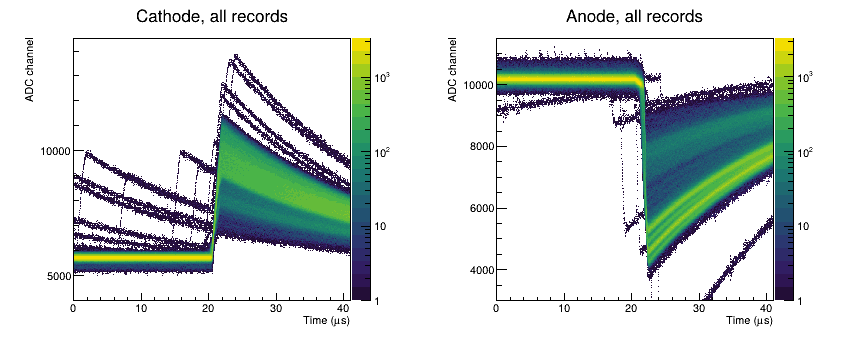

In [ ]:
c->Clear(); c->Divide(2,1); c->cd(1);
gPad->SetRightMargin(.16); gPad->SetLogz();
auto hrc=new TH2D("hrc","Cathode, all records;Time (#mus);ADC channel",1024,-.005,40.955,420,4000,14500);
hrc->SetMinimum(1);
tree->Draw("cathod:Iteration$*0.01>>hrc","","COLZ");
c->cd(2); gPad->SetRightMargin(.16); gPad->SetLogz();
auto hra=new TH2D("hra","Anode, all records;Time (#mus);ADC channel",1024,-.005,40.955,340,3000,11500);
hra->SetMinimum(1);
tree->Draw("anode:Iteration$*0.01>>hra","","COLZ");
tree->GetEntry(0); c->Draw();

## 2. 基线修正与波形观察

脉冲前的稳定部分给出基线 $b$，修正后 $y_k=x_k-b$。先看原始图，确认所选区间中没有信号；本例取前 1500 点。阳极再反号，后面两路都按正脉冲处理。基线的逐事件变化会直接影响幅度和长时间积分。

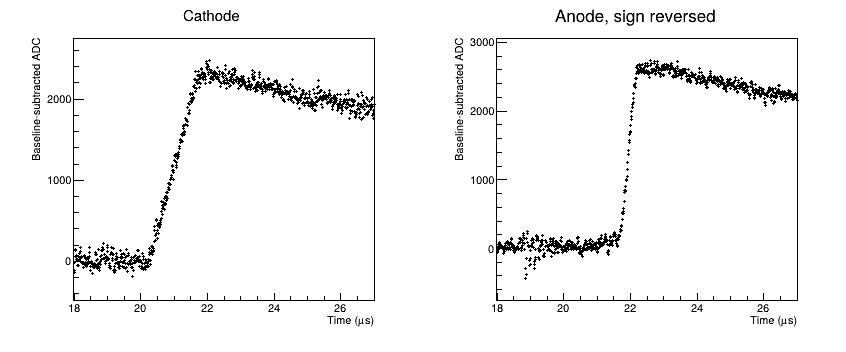

In [ ]:
double bc=0,ba=0,yc[n],ya[n],varc=0,vara=0;
for (int k=0; k<1500; ++k) {bc+=rawc[k]/1500.0; ba+=rawa[k]/1500.0;}
for (int k=0; k<n; ++k) {yc[k]=rawc[k]-bc; ya[k]=ba-rawa[k];}
for (int k=0; k<1500; ++k) {varc+=yc[k]*yc[k]/1500; vara+=ya[k]*ya[k]/1500;}
std::cout << "Baseline: cathode = " << bc << ", anode = " << ba << " ADC\n"
          << "Baseline RMS: cathode = " << std::sqrt(varc)
          << ", anode = " << std::sqrt(vara) << " ADC\n";
auto gc=new TGraph(n,t,yc); auto ga=new TGraph(n,t,ya);
c->Clear(); c->Divide(2,1);
TGraph* baselineGraphs[2]={gc,ga};
const char* names[2]={"Cathode","Anode, sign reversed"};
for (int j=0; j<2; ++j) {
    c->cd(j+1);
    baselineGraphs[j]->SetTitle(Form("%s;Time (#mus);Baseline-subtracted ADC",names[j]));
    baselineGraphs[j]->SetMarkerStyle(6); baselineGraphs[j]->Draw("AP");
    baselineGraphs[j]->GetXaxis()->SetRangeUser(18,27);
}
c->Draw();

### median filter 与 moving average

原实例用 median filter 抑制孤立尖峰，再用 moving average 平滑波形。下面保留这个例子：101 点 median 对应 1.01 μs，随后 21 点平均对应 0.21 μs。窗口已经接近脉冲的上升时间，因此除了降噪，也会改变波形细节。median filter 是非线性处理，不能据此认为电荷仍然严格守恒。

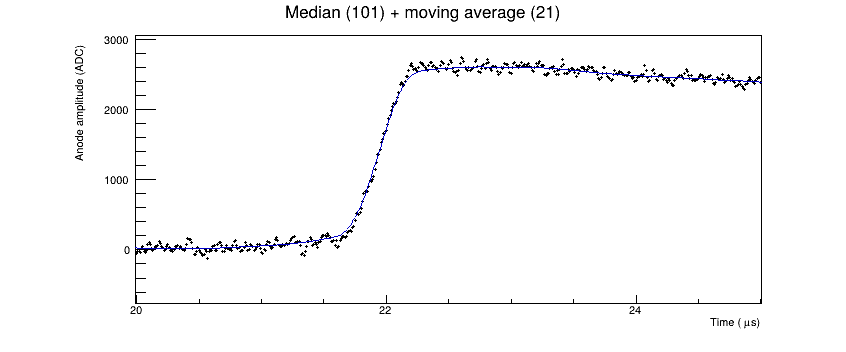

In [ ]:
double median[n],smooth[n],window[101];
std::copy(ya,ya+n,median);
for (int k=50; k<n-50; ++k) {
    std::copy(ya+k-50,ya+k+51,window);
    std::sort(window,window+101);
    median[k]=window[50];
}
std::copy(median,median+n,smooth);
for (int k=10; k<n-10; ++k)
    smooth[k]=std::accumulate(median+k-10,median+k+11,0.0)/21;
auto gs=new TGraph(n,t,smooth);
c->Clear();
ga->SetTitle("Median (101) + moving average (21);Time (#mus);Anode amplitude (ADC)");
ga->Draw("AP"); ga->GetXaxis()->SetRangeUser(20,25);
gs->SetLineColor(kBlue+1); gs->Draw("L SAME"); c->Draw();

### 基线修正与滤波前后的累积图

`gic_filtered.root` 保留配套 `fana.root` 中已经处理好的 5500 条记录，与原始数据逐事件对应。`cwave/awave` 是基线修正后的波形，`acwave/aawave` 是经过 101 点 median filter 和 21 点 moving average 的波形。该文件的基线取前 1900 点，单条波形示例取前 1500 点；两者都从脉冲前的区间估计基线。

下图在相同时间、幅度范围内比较：上排只修正基线，下排再滤波。阳极反号为正脉冲。滤波后带状结构更窄，但前沿和峰顶也会改变。

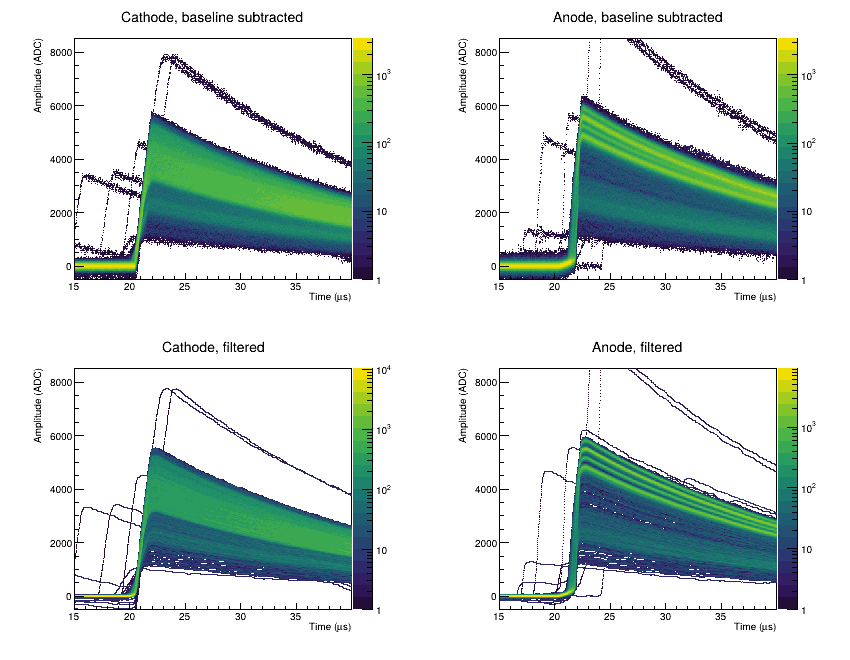

In [ ]:
auto filtered_file=TFile::Open("gic_filtered.root");
auto peaks=filtered_file->Get<TTree>("tree");
c->Clear(); c->SetCanvasSize(850,660); c->Divide(2,2);
const char* filteredExpr[4]={"cwave","-awave","acwave","-aawave"};
const char* filteredTitles[4]={"Cathode, baseline subtracted","Anode, baseline subtracted","Cathode, filtered","Anode, filtered"};
for (int panel=0; panel<4; ++panel) {
    c->cd(panel+1); gPad->SetRightMargin(.16); gPad->SetLogz();
    auto hist=new TH2D(Form("filtered_%d",panel+1),Form("%s;Time (#mus);Amplitude (ADC)",filteredTitles[panel]),625,14.995,39.995,360,-500,8500);
    hist->SetMinimum(1);
    peaks->Draw(Form("%s:Iteration$*0.01>>%s",filteredExpr[panel],hist->GetName()),"Iteration$>=1500 && Iteration$<4000","COLZ");
}
c->Draw();

### Anode vs. cathode：峰高关联

每个事件从滤波波形中取阴极最大值 `ec`、阳极最小值 `ea`，因此画 `-ea:ec`。这是能量相关的**峰高关联图**，纵横轴仍是 ADC；经过能量刻度后才可标成能量。阳极的四组 α 带与阴极幅度的变化，可与模拟中的前放峰高关联比较。

两轴均采用 10 ADC 的 bin。左图保留全谱范围，右图放大主要 α 带；放大图使用同一直方图，不重新调整 bin 或筛选事件。

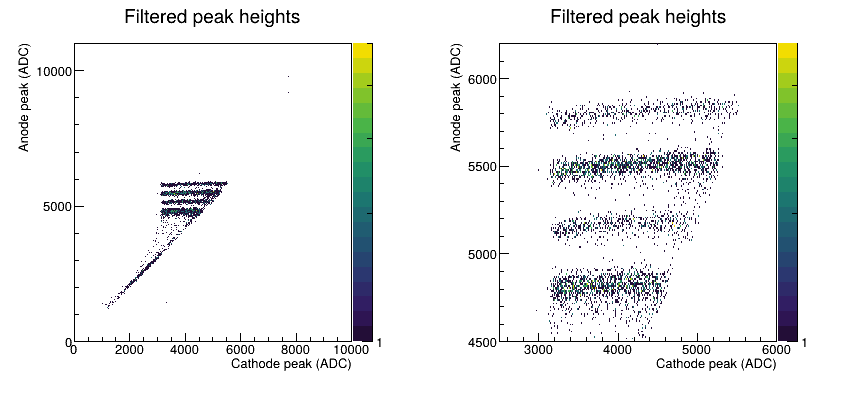

In [ ]:
std::vector<double> peak_c,peak_a;
for (int event=0; event<peaks->GetEntries(); ++event) {
    peaks->GetEntry(event);
    peak_c.push_back(peaks->GetLeaf("ec")->GetValue());
    peak_a.push_back(-peaks->GetLeaf("ea")->GetValue());
}
c->Clear(); c->SetCanvasSize(850,400); c->Divide(2,1);
auto hpeak=new TH2D("hpeak","Filtered peak heights;Cathode peak (ADC);Anode peak (ADC)",1000,0,10000,1100,0,11000);
hpeak->SetMinimum(1);
peaks->Draw("-ea:ec>>hpeak","","goff");
c->cd(1); gPad->SetRightMargin(.16); gPad->SetLogz(); hpeak->DrawCopy("COLZ");
c->cd(2); gPad->SetRightMargin(.16); gPad->SetLogz();
hpeak->GetXaxis()->SetRangeUser(2500,6000); hpeak->GetYaxis()->SetRangeUser(4500,6200);
hpeak->Draw("COLZ"); c->Draw();
std::cout << "Peak-height correlation: " << hpeak->GetEntries() << " events\n";

## 3. 从前放电压到电荷估计

由前放响应可得 $\mathrm du/\mathrm dt+u/\tau=i$，因此

$$Q(t)=u(t)+\frac1\tau\int_0^t u(t')\,\mathrm dt'.$$

对基线修正后的电压做同样处理，得到与电荷成正比的量。下面直接用原始的 `ya`，不经过上面的 median filter。取 $\tau=27$ μs；在实际测量中，可用无 pile-up 脉冲的衰减尾部检查这个时间常数。修正后若有系统性的上斜或下斜，应先检查基线和 $\tau$。

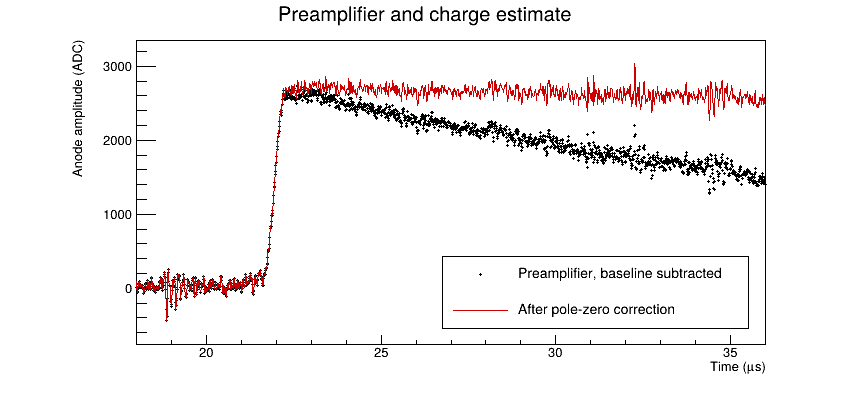

In [ ]:
double tau=27.0,q[n],integral=0;
for (int k=0; k<n; ++k) {integral+=ya[k]*dt; q[k]=ya[k]+integral/tau;}
auto gq=new TGraph(n,t,q);
c->Clear();
ga->SetTitle("Preamplifier and charge estimate;Time (#mus);Anode amplitude (ADC)");
ga->Draw("AP"); ga->GetXaxis()->SetRangeUser(18,36);
ga->SetMaximum(1.1*(*std::max_element(q,q+n)));
gq->SetLineColor(kRed+1); gq->Draw("L SAME");
auto leg=new TLegend(.52,.18,.88,.36);
leg->AddEntry(ga,"Preamplifier, baseline subtracted","p");
leg->AddEntry(gq,"After pole-zero correction","l"); leg->Draw(); c->Draw();

这一步去除了理想前放的指数衰减，没有把噪声消除；长时间累积还会放大基线偏差。测量电荷时，通常再用有限时间长度的成型滤波器。

## 4. 梯形成型与幅度提取

对电荷阶跃 $q_k$ 分别取两段等长的滑动平均，再作差：

$$m_k=\frac1L\sum_{j=0}^{L-1}q_{k-j},\qquad
h_k=m_k-m_{k-L-G}.$$

瞬时电荷输入会得到梯形：上升段和下降段各长 $L\Delta t$，中间 flat top 长 $G\Delta t$。有限电荷收集时间会缩短可用的平台，所以本例取 $L\Delta t=1$ μs、$G\Delta t=3$ μs，给 GIC 的电荷收集留出时间。平台幅度对应收集电荷，而不再直接依赖前放峰顶。

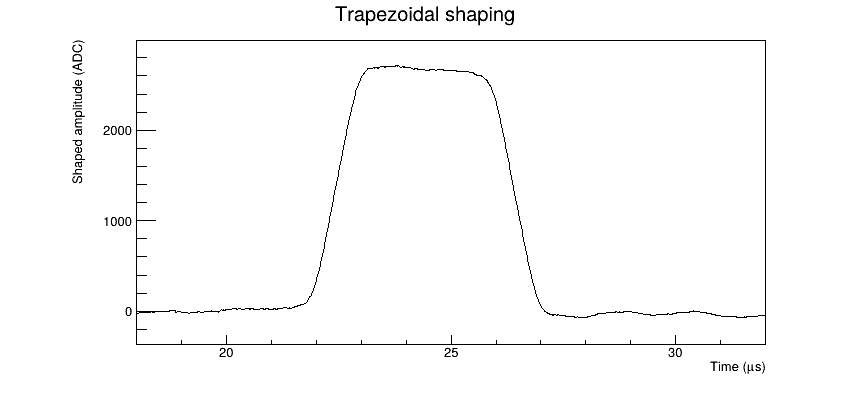

In [ ]:
const int L=100,G=300;
double m[n],shaped[n],running=0;
for (int k=0; k<n; ++k) {
    running+=q[k];
    if (k>=L) running-=q[k-L];
    m[k]=running/L;
    shaped[k]=m[k];
    if (k>=L+G) shaped[k]-=m[k-L-G];
}
auto gh=new TGraph(n,t,shaped);
c->Clear();
gh->SetTitle("Trapezoidal shaping;Time (#mus);Shaped amplitude (ADC)");
gh->Draw("AL"); gh->GetXaxis()->SetRangeUser(18,32); c->Draw();
int peak_index=std::max_element(shaped+2200,shaped+3000)-shaped;
double amplitude=std::accumulate(shaped+peak_index-10,shaped+peak_index+11,0.0)/21;
std::cout << "Shaped anode amplitude = " << amplitude << " ADC\n";

先看平台是否覆盖完整收集过程，再在平台上取平均。本例在搜索到的平台高点附近取 21 点平均；用于精密测量时，可用触发位置定义固定的读出区间，减少从噪声中选最大值造成的偏差。改变 $L$ 可比较噪声与成型时间的取舍；$G$ 太短时，长上升时间脉冲仍会出现 ballistic deficit。

## 5. 时间信息：上升时间与 CFD

幅度测量与时间测量使用同一条波形，但可以采用不同滤波。下面只用 21 点 moving average 稳定前沿。定义 $t_{10}$、$t_{90}$ 为前沿达到峰值 10%、90% 的时刻，上升时间为 $t_{90}-t_{10}$。

CFD 将一个延迟信号与一个衰减信号相减：

$$c_k=f y_k-y_{k-d_t}.$$

在正确的前沿上取零交叉作为时间标记。对于形状相同、幅度不同的脉冲，整体幅度因子不会改变零交叉；但 GIC 的形状随径迹方向变化，因此 CFD 时间也不能直接当成粒子的产生时刻。

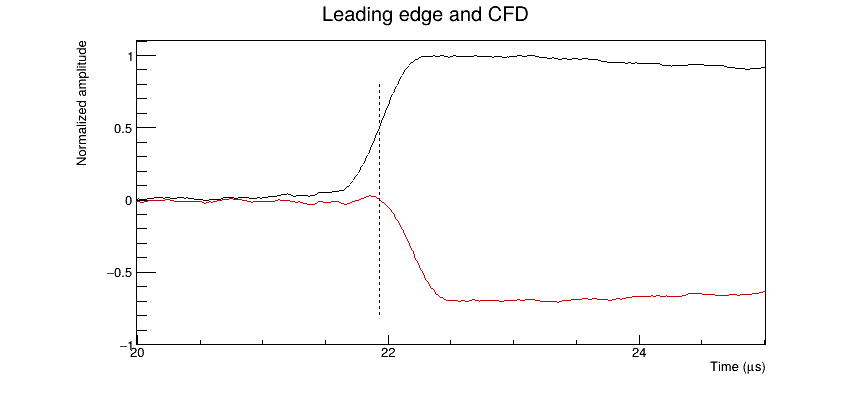

In [ ]:
double timing[n]={0},cfd[n]={0},normal[n],cfNormal[n];
for (int k=10; k<n-10; ++k)
    timing[k]=std::accumulate(ya+k-10,ya+k+11,0.0)/21;
int imax=std::max_element(timing+1900,timing+2600)-timing;
double height=timing[imax],crossings[2];
for (int j=0; j<2; ++j) {
    double threshold=(j==0 ? .1 : .9)*height;
    int k=1900;
    while (k<imax && timing[k]<threshold) ++k;
    crossings[j]=t[k-1]+dt*(threshold-timing[k-1])/(timing[k]-timing[k-1]);
}
double t10=crossings[0],t90=crossings[1],fraction=.3;
int delay=20;
for (int k=0; k<n; ++k) {
    cfd[k]=fraction*timing[k]; if (k>=delay) cfd[k]-=timing[k-delay];
    normal[k]=timing[k]/height; cfNormal[k]=cfd[k]/height;
}
int k=std::max(1900,int(t10/dt));
while (k<imax+delay && !(cfd[k]>0 && cfd[k+1]<=0)) ++k;
if (k==imax+delay) throw std::runtime_error("No CFD crossing on leading edge");
double tcfd=t[k]+dt*cfd[k]/(cfd[k]-cfd[k+1]);
std::cout << "t10 = " << t10 << "; t90 = " << t90 << "; rise time = " << t90-t10
          << " us\nCFD crossing = " << tcfd << " us, relative to record start\n";
auto gt=new TGraph(n,t,normal); auto gf=new TGraph(n,t,cfNormal);
c->Clear(); gt->SetTitle("Leading edge and CFD;Time (#mus);Normalized amplitude");
gt->Draw("AL"); gt->GetXaxis()->SetRangeUser(20,25); gt->SetMinimum(-1);
gf->SetLineColor(kRed+1); gf->Draw("L SAME");
auto mark=new TLine(tcfd,-.8,tcfd,.8); mark->SetLineStyle(2); mark->Draw(); c->Draw();

黑线是归一化的前沿，红线是 CFD 输出，虚线标出所选零交叉。

记录起点是采集系统给出的，不是电离发生时刻；上升时间也不是电子的全部漂移时间。若要由 $v_{\rm cg}=D/T_d$ 测漂移速度，应识别从电离开始到最晚电子到栅的时间 $T_d$。阴极波形及其差分可共同帮助确定这些特征，具体方法参见文献 [2]。不能直接把上面的 $t_{90}-t_{10}$ 代入。

GIC 的两路定时还可利用阴极二次差分与阳极一次差分的边缘特征。不同定时算法的时间基准要单独确认，能量谱不应默认只保留定时成功的事件。

## 6. 逐事件提取与二维关联

把上面的基线修正、pole-zero correction 和梯形成型用于每个事件，保存阴极、阳极的成型幅度。这里不加能量或时间 cut，先看全部事件的关联。

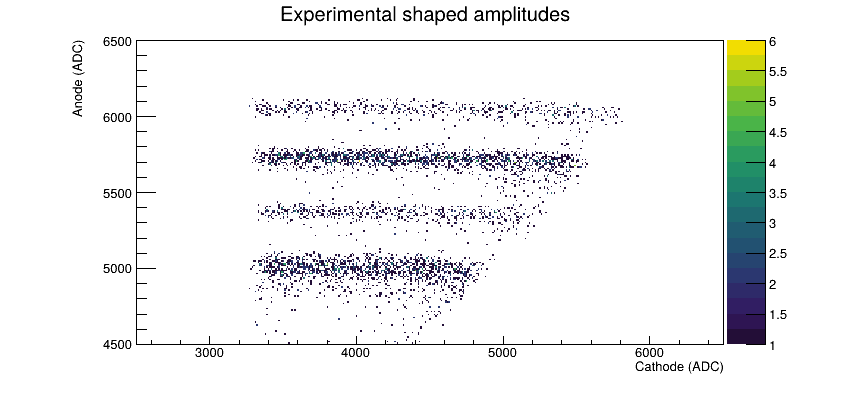

In [ ]:
std::vector<double> ac,aa;
for (int event=0; event<tree->GetEntries(); ++event) {
    tree->GetEntry(event);
    double values[2];
    for (int channel=0; channel<2; ++channel) {
        float* raw=(channel==0 ? rawc : rawa);
        double sign=(channel==0 ? 1 : -1),base=0,total=0,run=0;
        double charge[n],mean[n],h[n];
        for (int k=0; k<1500; ++k) base+=raw[k]/1500.0;
        for (int k=0; k<n; ++k) {
            double y=sign*(raw[k]-base);
            total+=y; charge[k]=y+dt/tau*total;
            run+=charge[k]; if (k>=L) run-=charge[k-L];
            mean[k]=run/L; h[k]=mean[k];
            if (k>=L+G) h[k]-=mean[k-L-G];
        }
        int peak=std::max_element(h+2200,h+3000)-h;
        values[channel]=std::accumulate(h+peak-10,h+peak+11,0.0)/21;
    }
    ac.push_back(values[0]); aa.push_back(values[1]);
}
c->Clear(); c->SetRightMargin(.15);
auto hca=new TH2D("hca","Experimental shaped amplitudes;Cathode (ADC);Anode (ADC)",1000,0,10000,1100,0,11000);
hca->SetMinimum(1);
std::ofstream results("gic_amplitudes.txt");
results << std::setprecision(17);
for (int j=0; j<(int)ac.size(); ++j) {hca->Fill(ac[j],aa[j]); results << ac[j] << " " << aa[j] << "\n";}
results.close(); hca->Draw("COLZ");
hca->GetXaxis()->SetRangeUser(2500,6500); hca->GetYaxis()->SetRangeUser(4500,6500);
c->Draw();
std::cout << "Processed " << ac.size() << " events; saved gic_amplitudes.txt\n";

图中放大了四组 α 带所在区域，直方图仍填入全部 5500 个事件，两轴的 bin 宽度同样为 10 ADC。与前面的峰高关联相比，这里使用的是经过 pole-zero correction 和梯形成型的幅度。实验条带有宽度、斜率和少量离群点；对比理想图时，应区分电荷输运、电子学响应与事件选择的影响。

### 从成型幅度到物理量

用标准 α 能量确定阳极的能量刻度，例如 $E=a_a+b_a A_a$。刻度的是经过同一套处理得到的成型幅度，不能直接沿用前放峰高的系数。

阴极与阳极的增益分别刻度后，可将幅度换成上一节的 $Q_c$、$Q_a$。理想关系给出

$$\cos\theta=\frac{D}{\bar s(E)}\left(1-\frac{Q_c}{Q_a}\right),\qquad E=Q_a.$$

这里 $\bar s(E)$ 来自对应能量的电离分布。没有两路刻度或附着、栅极效率的修正时，原始幅度比只能作为角度代理，不能直接报告精确角度。

<a id="comparison"></a>

## 7. 实验与模拟波形比较

在前面的**峰高关联图**中，选择最高能量 α 带的两端：相近的阳极幅度对应同一组 α 能量，较低、较高的阴极幅度分别偏向 $\theta\approx0^\circ$ 和 $\theta\approx90^\circ$。这里 $\theta$ 仍相对于漂移方向定义。实验窗口有有限宽度，只选择了偏向这些方向的事件，不能将窗口内每个事件都赋予精确的 $0^\circ$ 或 $90^\circ$。

先在关联图上标出选择范围，再检查它们对应的两路波形。下图放大最高能量带；蓝框和红框分别取阴极幅度较低、较高的部分。

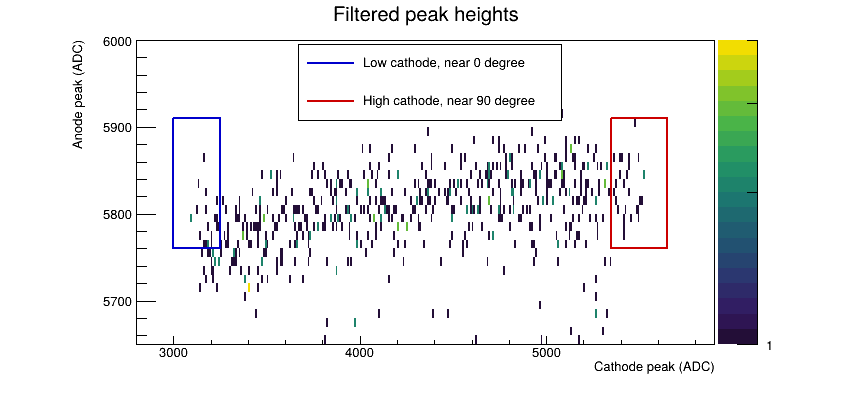

In [ ]:
const char* low_cut="-ea>5760 && -ea<5910 && ec>3000 && ec<3250";
const char* high_cut="-ea>5760 && -ea<5910 && ec>5350 && ec<5650";
c->Clear(); c->SetCanvasSize(850,400); c->SetRightMargin(.16); c->SetLogz();
hpeak->GetXaxis()->SetRangeUser(2800,5900); hpeak->GetYaxis()->SetRangeUser(5650,6000);
hpeak->Draw("COLZ");
auto gate_low=new TBox(3000,5760,3250,5910);
auto gate_high=new TBox(5350,5760,5650,5910);
gate_low->SetFillStyle(0); gate_low->SetLineColor(kBlue+1); gate_low->SetLineWidth(2); gate_low->Draw();
gate_high->SetFillStyle(0); gate_high->SetLineColor(kRed+1); gate_high->SetLineWidth(2); gate_high->Draw();
auto gate_legend=new TLegend(.35,.7,.66,.89);
gate_legend->AddEntry(gate_low,"Low cathode, near 0 degree","l");
gate_legend->AddEntry(gate_high,"High cathode, near 90 degree","l");
gate_legend->Draw(); c->Draw();

### 所选事件的波形累积

这里读取仅做过基线修正的 `cwave/awave`，不使用 median filter 后的波形；保留事件之间的噪声、幅度差和到达时间差。各图使用相同的时间轴与幅度轴，bin 宽度分别为 40 ns 和 25 ADC。

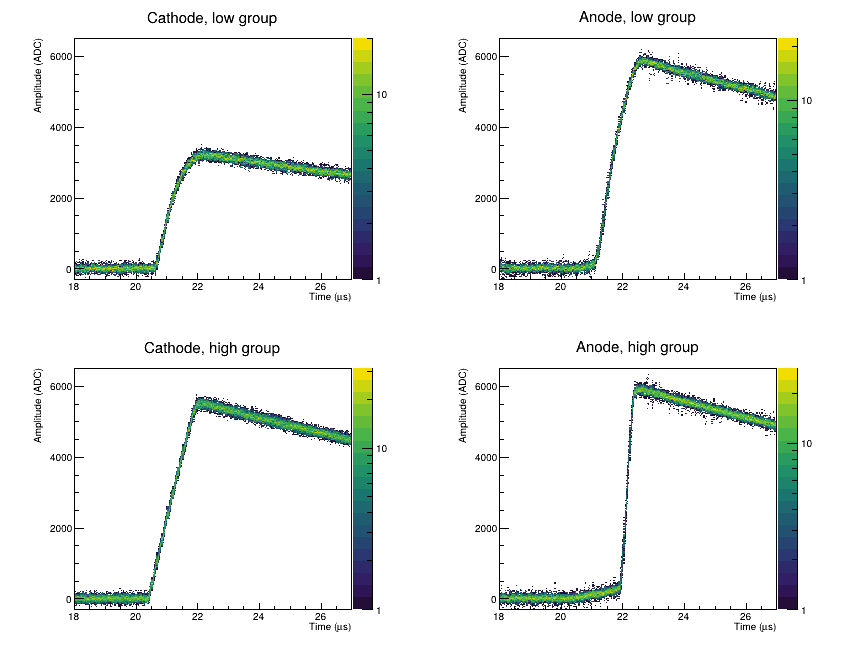

In [ ]:
c->Clear(); c->SetLogz(false); c->SetCanvasSize(850,660); c->Divide(2,2);
const char* selectedExpr[4]={"cwave","-awave","cwave","-awave"};
const char* selectedTitles[4]={"Cathode, low group","Anode, low group","Cathode, high group","Anode, high group"};
for (int panel=0; panel<4; ++panel) {
    c->cd(panel+1); gPad->SetRightMargin(.16); gPad->SetLogz();
    auto hist=new TH2D(Form("selected_%d",panel+1),Form("%s;Time (#mus);Amplitude (ADC)",selectedTitles[panel]),225,17.995,26.995,272,-300,6500);
    hist->SetMinimum(1);
    peaks->Draw(Form("%s:Iteration$*0.01>>%s",selectedExpr[panel],hist->GetName()),Form("(%s) && Iteration$>=1800 && Iteration$<2700",panel<2 ? low_cut : high_cut),"COLZ");
}
c->Draw();
std::cout << "Selected events: low = " << peaks->GetEntries(low_cut)
          << ", high = " << peaks->GetEntries(high_cut) << "\n";

### 与模拟的形状比较

下面仍用同一批选中事件，从原始记录重新估计基线并计算平均波形，随后与 5.805 MeV 的两种方向模板比较。

In [ ]:
std::vector<int> low,high;
for (int j=0; j<(int)peak_c.size(); ++j) {
    if (peak_a[j]>5760 && peak_a[j]<5910 && peak_c[j]>3000 && peak_c[j]<3250) low.push_back(j);
    if (peak_a[j]>5760 && peak_a[j]<5910 && peak_c[j]>5350 && peak_c[j]<5650) high.push_back(j);
}
std::cout << "Low cathode group: " << low.size() << "; high cathode group: " << high.size() << "\n";
double averages[4][n]={0};
for (int group=0; group<2; ++group) {
    const std::vector<int>& indices=(group==0 ? low : high);
    if (indices.empty()) throw std::runtime_error("Empty amplitude selection");
    for (int index : indices) {
        tree->GetEntry(index);
        double bc=0,ba=0;
        for (int k=0; k<1500; ++k) {bc+=rawc[k]/1500.0; ba+=rawa[k]/1500.0;}
        for (int k=0; k<n; ++k) {
            averages[2*group][k]+=(rawc[k]-bc)/indices.size();
            averages[2*group+1][k]+=(ba-rawa[k])/indices.size();
        }
    }
}

比较前统一极性，再以组内平均波形的前沿 10% 位置为时间零点、平均波形峰高为幅度单位；同组所有事件使用同一变换，不逐条平移或缩放。颜色保留实验波形的分布，蓝线是平均波形，红线是单角度模拟。模拟也按自身前沿的 10% 位置与峰高归一化，比较的是形状而不是绝对增益。

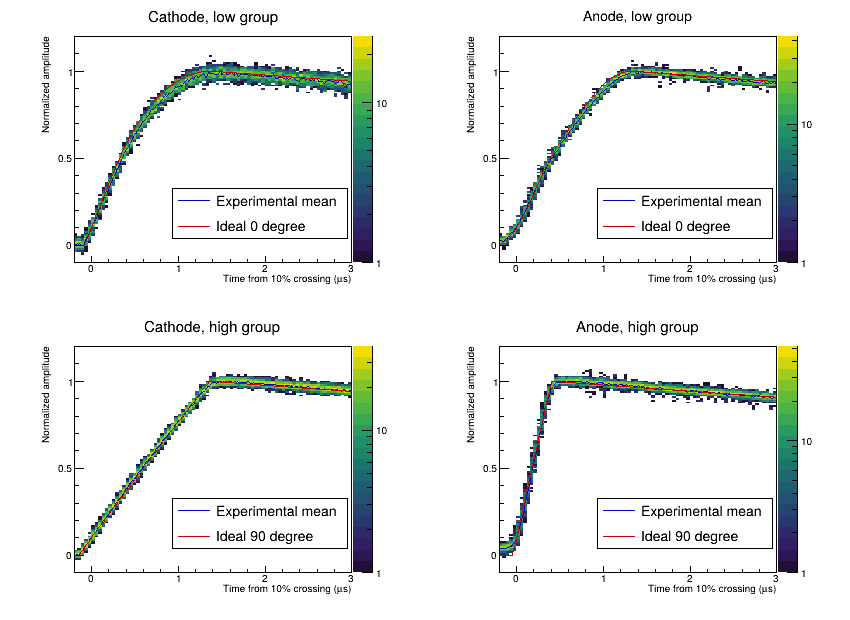

In [ ]:
std::ifstream input("gic_templates.txt");
std::vector<double> ts,sim[4];
double time,value[4];
while (input >> time >> value[0] >> value[1] >> value[2] >> value[3]) {
    ts.push_back(time);
    for (int j=0; j<4; ++j) sim[j].push_back(value[j]);
}
if (ts.empty()) throw std::runtime_error("Run GIC_simulation first");
c->Clear(); c->SetCanvasSize(850,620); c->Divide(2,2);
const char* titles[4]={"Cathode, low group","Anode, low group","Cathode, high group","Anode, high group"};
for (int panel=0; panel<4; ++panel) {
    c->cd(panel+1);
    double* exp=averages[panel];
    int peak=std::max_element(exp+1900,exp+2600)-exp;
    int k=1900; while (exp[k]<=.1*exp[peak]) ++k;
    double t0=t[k-1]+dt*(.1*exp[peak]-exp[k-1])/(exp[k]-exp[k-1]);
    double maximum=*std::max_element(sim[panel].begin(),sim[panel].end());
    int ks=1; while (sim[panel][ks]<=.1*maximum) ++ks;
    double ts0=ts[ks-1]+dt*(.1*maximum-sim[panel][ks-1])/(sim[panel][ks]-sim[panel][ks-1]);
    auto ge=new TGraph(); auto gm=new TGraph();
    for (int j=0; j<n; ++j) ge->SetPoint(j,t[j]-t0,exp[j]/exp[peak]);
    for (int j=0; j<(int)ts.size(); ++j) gm->SetPoint(j,ts[j]-ts0,sim[panel][j]/maximum);
    auto density=new TH2D(Form("compare_%d",panel),Form("%s;Time from 10%% crossing (#mus);Normalized amplitude",titles[panel]),80,-.2,3,130,-.1,1.2);
    density->SetMinimum(1);
    const std::vector<int>& indices=(panel<2 ? low : high);
    for (int index : indices) {
        tree->GetEntry(index);
        float* raw=(panel%2==0 ? rawc : rawa);
        double base=0, sign=(panel%2==0 ? 1 : -1);
        for (int j=0; j<1500; ++j) base+=raw[j]/1500.0;
        for (int j=1800; j<2800; ++j) density->Fill(t[j]-t0,sign*(raw[j]-base)/exp[peak]);
    }
    gPad->SetRightMargin(.16); gPad->SetLogz(); density->Draw("COLZ");
    ge->SetLineColor(kBlue+1); gm->SetLineColor(kRed+1);
    ge->Draw("L SAME");
    gm->Draw("L SAME");
    auto lg=new TLegend(.4,.22,.83,.39);
    lg->AddEntry(ge,"Experimental mean","l");
    lg->AddEntry(gm,panel<2 ? "Ideal 0 degree" : "Ideal 90 degree","l"); lg->Draw();
}
c->Draw();

阳极在低阴极幅度组中的上升沿更缓，高幅度组则对应更集中的电子到达时刻；阴极本身在低幅度组中呈弯曲的上升沿，高幅度组更接近线性上升，与模型的方向依赖对应。理想曲线不含前放有限带宽、扩散、附着和栅极非屏蔽；有限选择窗中还混有不同角度，不能期待平均实验波形与单角度模板完全重合。

若形状不同，先核对气体与漂移速度、两路带宽和前放 $\tau$，再讨论输运模型；不通过任意平移、展宽或额外噪声把曲线调到重合。对齐消除了绝对时间差，归一化消除了幅度差，能量与时间的检验仍需保留未归一化的数据。

## 8. 完整信号链中的对应关系

| 阶段 | 量 | 从中提取或检查什么 |
| --- | --- | --- |
| α 在气体中电离 | $\Delta E_j$、$N_{e,j}$、位置 $s_j$ | 能量沉积与径迹 |
| 电荷漂移与电极感应 | $i_c(t)$、$i_a(t)$，积分为 $Q_c$、$Q_a$ | 能量与角度依赖 |
| 前放与数字化 | $V(t)$、ADC 波形 | 极性、时间常数、采样与噪声 |
| pole-zero correction 与梯形成型 | 电荷估计与 flat-top 幅度 | 经刻度后的能量 |
| 前沿与定时滤波 | $t_{10}$、$t_{90}$、CFD 时间 | 上升时间和相对时间标记 |
| 两路关联与校准 | $Q_c/Q_a$、能量带、波形形状 | 角度信息、输运与电子学响应 |

## 参考文献

1. J. Liu et al., “The impacts of the ballistic deficit and electron attachment on the pulse shapes of the Frisch-grid ionization chamber,” *Nucl. Instrum. Methods A* **1014**, 165751 (2021). [DOI](https://doi.org/10.1016/j.nima.2021.165751).
2. J. Liu et al., “Improved method to measure the electron drift velocity using the Frisch-grid ionization chamber,” *Nucl. Instrum. Methods A* **1004**, 165363 (2021). [DOI](https://doi.org/10.1016/j.nima.2021.165363).
3. J. Liu et al., “Research on the electron attachment of oxygen using a Frisch-grid ionization chamber,” *Nucl. Instrum. Methods A* **1013**, 165669 (2021). [DOI](https://doi.org/10.1016/j.nima.2021.165669).